<a href="https://colab.research.google.com/github/stacykeago/predictive-data-analytics/blob/main/Q1336017_KEAGO_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# a. EXPLORATORY DATA ANALYSIS (EDA)

In [44]:
import numpy as np                                   # for linear algebra
import pandas as pd                                  # for data processing
import matplotlib.pyplot as plt                      # for data visualization
import seaborn as sns                                # for statistical data visualization
from sklearn.preprocessing import LabelEncoder        # for encoding binary categorical columns
from sklearn.preprocessing import StandardScaler       # for normalization/scaling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
def variance_inflation_factor(X, i):
    import numpy as np
    cols = [c for c in range(X.shape[1]) if c != i]
    yv = X[:, i]
    Xv = X[:, cols]
    r2 = LinearRegression().fit(Xv, yv).score(Xv, yv)
    return 1/(1-r2) if r2 < 0.999 else float("inf")
from scipy import stats                              # for hypothesis testing
import warnings
warnings.filterwarnings("ignore")


In [45]:
# Force pandas to display ALL columns and rows without truncation
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# 1. Read the dataset into a dataframe called "loan"
loan = pd.read_csv("Loan_Default.csv")

# 2. Preview the first 10 rows
loan.head(10)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.560,0.2000,595.00,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.250,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.000,0.3042,0.00,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,706500,3.990,0.1523,370.00,360.0,not_neg,not_int,not_lpsm,1008000.0,sb,pr,home,1U,10080.0,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,346500,4.500,0.9998,5120.00,360.0,not_neg,not_int,not_lpsm,438000.0,sb,pr,home,1U,5040.0,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
7,24897,2019,NaN,Female,nopre,type1,p4,l1,nopc,nob/c,266500,4.125,0.2975,5609.88,360.0,not_neg,not_int,not_lpsm,308000.0,sb,pr,home,1U,3780.0,CIB,863,CIB,55-64,to_inst,86.525974,North,direct,0,42.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,376500,4.875,0.7395,1150.00,360.0,not_neg,not_int,not_lpsm,478000.0,sb,pr,home,1U,5580.0,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
9,24899,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,436500,3.490,-0.2776,2316.50,360.0,not_neg,not_int,not_lpsm,688000.0,sb,pr,home,1U,6720.0,CIB,788,EXP,55-64,to_inst,63.444767,south,direct,0,30.0


In [46]:
loan.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1'], dtype='object')

In [6]:
# Print number of rows and columns
print(f"Rows: {loan.shape[0]}, Columns: {loan.shape[1]}")

Rows: 142340, Columns: 34


In [47]:
# Numeric summary
loan.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [10]:
# Categorical summary
loan.describe(include="object")

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,Neg_ammortization,interest_only,lump_sum_payment,construction_type,occupancy_type,Secured_by,total_units,credit_type,co-applicant_credit_type,age,submission_of_application,Region,Security_Type
count,139128,142340,141462,142340,142215,142340,142340,142340,142224,142339,142339,142339,142339,142339,142339,142339,142339,142146,142146,142339,142339
unique,2,4,2,3,4,2,2,2,2,2,2,2,3,2,4,4,2,7,2,4,2
top,cf,Male,nopre,type1,p3,l1,nopc,nob/c,not_neg,not_int,not_lpsm,sb,pr,home,1U,CIB,CIB,45-54,to_inst,North,direct
freq,129573,40568,119277,108332,53545,136281,141809,122441,127749,135530,139114,142308,132330,142308,140246,46108,71238,33230,91789,71538,142308


In [48]:
# Check every column for characters other than letters, numbers, whitespace, '.', '-', '_' and '+'
# ('_' and '+' are allowed because they appear in legitimate category labels like "debt_consolidation" and "3+")
for col in loan.columns:
    count = loan[col].astype(str).str.contains(r"[^a-zA-Z0-9\s.\-_+]", na=False).sum()
    if count > 0:
        print(f"Column '{col}' has {count} rows with symbols.")


Column 'business_or_commercial' has 148670 rows with symbols.
Column 'age' has 8512 rows with symbols.


In [14]:
loan[["income", "rate_of_interest", "business_or_commercial"]].sample(8, random_state=1)

,income,rate_of_interest,business_or_commercial
80344,5940.0,3.990,nob/c
83501,7320.0,3.375,nob/c
70621,14460.0,4.875,nob/c
50684,4680.0,3.625,nob/c
5650,9480.0,4.990,nob/c
108880,NaN,4.125,b/c
37998,4920.0,NaN,nob/c
27318,8280.0,3.625,nob/c


In [18]:

# 1. Strip "$" and "," from income, then convert to numeric
loan["income"] = loan["income"].astype(str).str.replace(r"[$,]", "", regex=True)
loan["income"] = pd.to_numeric(loan["income"], errors="coerce")

In [16]:
# If it's stored as text, convert it directly to numeric
loan["income"] = pd.to_numeric(loan["income"], errors="coerce")

In [19]:
# Now check missing values properly
loan.isnull().sum()

,0
ID,0
year,0
loan_limit,3212
Gender,0
approv_in_adv,878
loan_type,0
loan_purpose,125
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [21]:
# 1. Continuous numeric columns -> impute with the MEDIAN
numeric_cols_to_impute = ["income", "Credit_Score", "term", "dtir1"]
for col in numeric_cols_to_impute:
    loan[col] = pd.to_numeric(loan[col], errors="coerce")
    loan[col] = loan[col].fillna(loan[col].median())

# 2. Categorical column (e.g., business_or_commercial) -> impute with the MODE
loan["business_or_commercial"] = loan["business_or_commercial"].fillna(loan["business_or_commercial"].mode()[0])

# 3. Verify clean results
print(loan[numeric_cols_to_impute + ["business_or_commercial"]].isnull().sum())

income                    0
Credit_Score              0
term                      0
dtir1                     0
business_or_commercial    0
dtype: int64


In [22]:
# Duplicates are noise to the data
print("Number of duplicate rows:", loan.duplicated().sum())
loan.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", loan.shape)


Number of duplicate rows: 0
Shape after removing duplicates: (142340, 34)


In [25]:
# Count of unique values for each column
print(loan.nunique())

# List the unique values for your ACTUAL categorical columns
categorical_cols = ["Gender", "Region", "loan_purpose", "loan_type", "business_or_commercial", "occupancy_type", "credit_type"]
for col in categorical_cols:
    # Dropna handles missing values so sorted() doesn't fail on mixed types
    unique_vals = sorted(loan[col].dropna().unique().tolist())
    print(f"{col} ({loan[col].nunique()} unique values): {unique_vals}")

ID                           142340
year                              1
loan_limit                        2
Gender                            4
approv_in_adv                     2
loan_type                         3
loan_purpose                      4
Credit_Worthiness                 2
open_credit                       2
business_or_commercial            2
loan_amount                     211
rate_of_interest                132
Interest_rate_spread          22334
Upfront_charges               56147
term                             26
Neg_ammortization                 2
interest_only                     2
lump_sum_payment                  2
property_value                  385
construction_type                 2
occupancy_type                    3
Secured_by                        2
total_units                       4
income                          992
credit_type                       4
Credit_Score                    401
co-applicant_credit_type          2
age                         

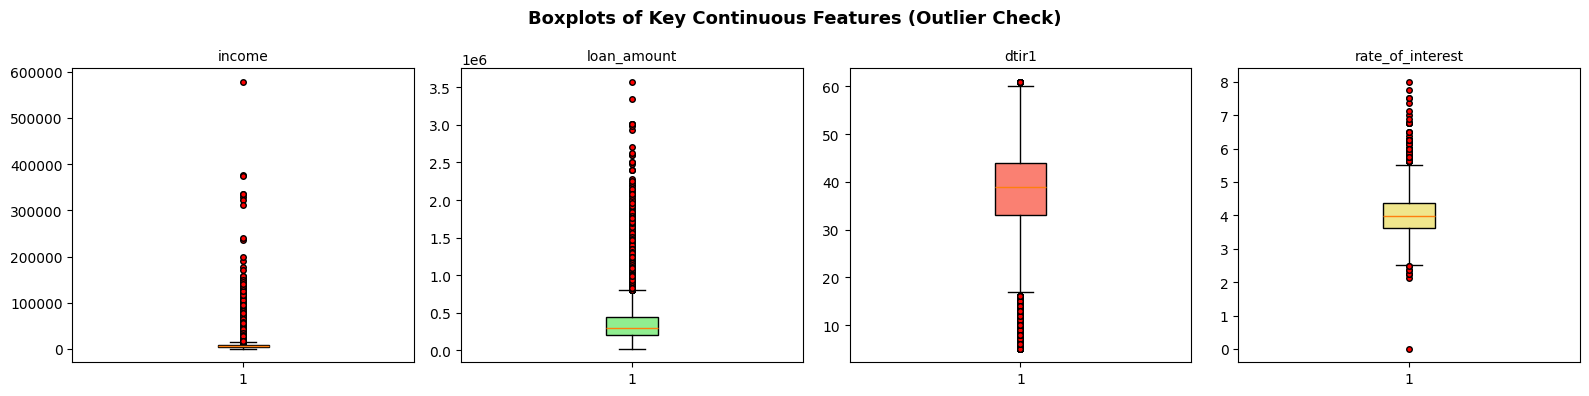

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Boxplots of Key Continuous Features (Outlier Check)", fontsize=13, fontweight="bold")

for ax, col, color in zip(axes, ["income", "loan_amount", "dtir1", "rate_of_interest"],
                           ["skyblue", "lightgreen", "salmon", "khaki"]):
    ax.boxplot(loan[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, color="black"),
               flierprops=dict(markerfacecolor="red", marker="o", markersize=4))
    ax.set_title(col, fontsize=10)

plt.tight_layout()
plt.savefig("outliers.png")

In [27]:
# Quantify outliers using the IQR rule
for col in ["income", "loan_amount", "dtir1", "rate_of_interest"]:
    q1, q3 = loan[col].quantile(0.25), loan[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((loan[col] < lower) | (loan[col] > upper)).sum()
    print(f"{col:<18} -> {n_outliers} outliers (outside [{lower:,.1f}, {upper:,.1f}])")

income             -> 7316 outliers (outside [-2,820.0, 14,940.0])
loan_amount        -> 1803 outliers (outside [-163,500.0, 796,500.0])
dtir1              -> 5258 outliers (outside [16.5, 60.5])
rate_of_interest   -> 818 outliers (outside [2.5, 5.5])


In [28]:
for col in ["income", "loan_amount"]:
    cap = loan[col].quantile(0.995)
    n_capped = (loan[col] > cap).sum()
    loan[col] = np.where(loan[col] > cap, cap, loan[col])
    print(f"{col}: capped {n_capped} extreme values at {cap:,.0f}")

income: capped 711 extreme values at 34,140
loan_amount: capped 707 extreme values at 1,006,500


In [30]:
loan.drop(columns=["ID"], inplace=True, errors="ignore")
print("Remaining columns:", loan.columns.tolist())

# View summary statistics
loan.describe()

Remaining columns: ['year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']


,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,142340.0,1.423400e+05,107424.000000,107230.000000,104374.000000,142340.000000,1.278490e+05,142340.000000,142340.000000,127849.000000,142339.000000,142340.000000
mean,2019.0,3.294625e+05,4.045470,0.441952,3226.762219,335.167142,4.977573e+05,6766.141492,699.758248,72.762732,0.246658,37.950204
std,0.0,1.747260e+05,0.561183,0.513072,3251.513795,58.379897,3.602874e+05,4637.257717,115.908673,40.653419,0.431067,9.657175
min,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,2019.0,1.965000e+05,3.625000,0.076425,581.840000,360.000000,2.680000e+05,3840.000000,599.000000,60.474860,0.000000,33.000000
50%,2019.0,2.965000e+05,3.990000,0.390600,2597.700000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,2019.0,4.365000e+05,4.375000,0.775875,4815.000000,360.000000,6.280000e+05,8280.000000,800.000000,86.184211,0.000000,44.000000
max,2019.0,1.006500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,34140.000000,900.000000,7831.250000,1.000000,61.000000


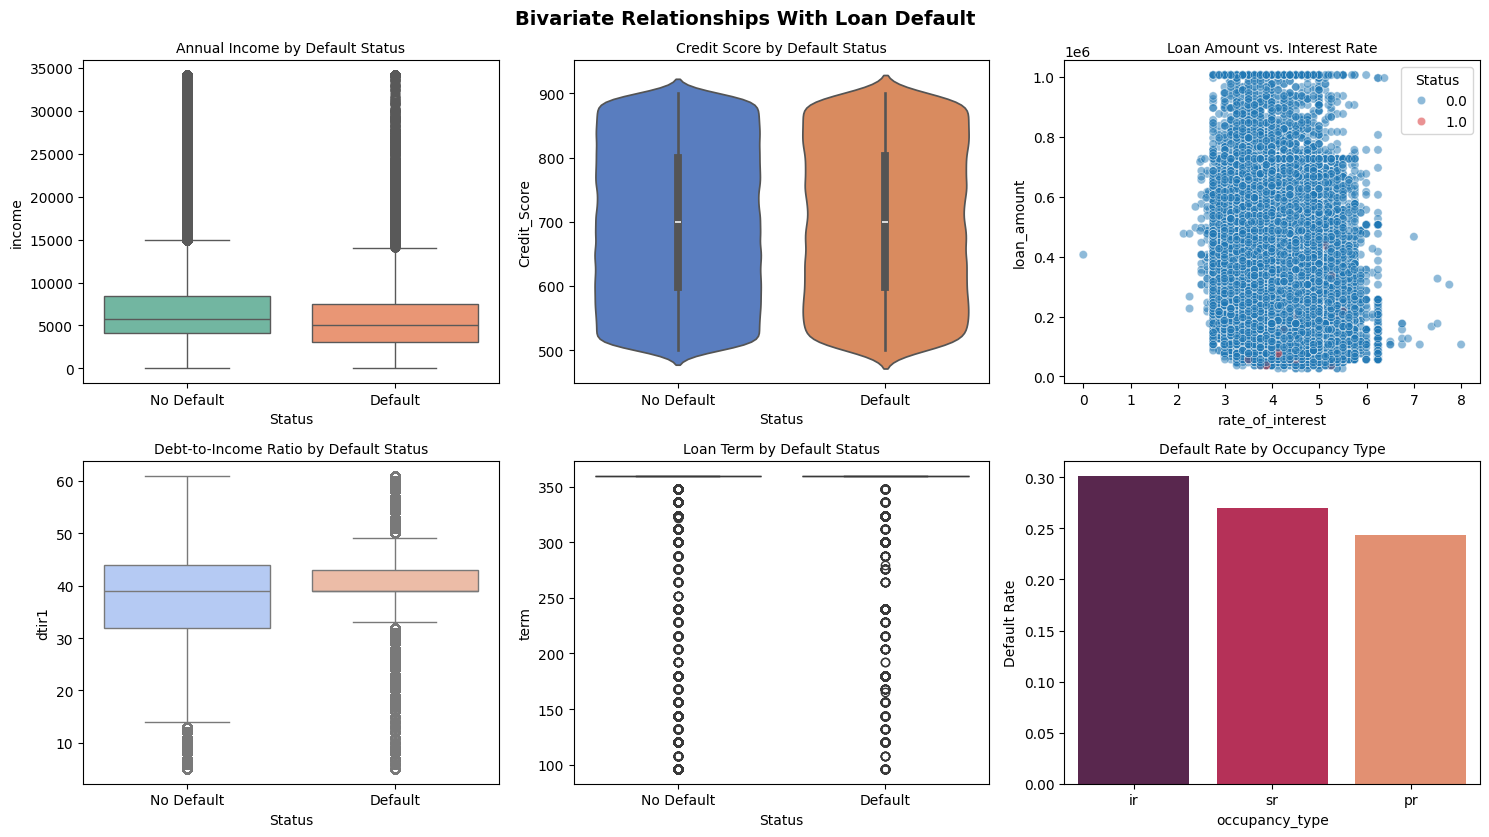

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
axes = axes.flatten()
plt.suptitle("Bivariate Relationships With Loan Default", fontsize=14, fontweight="bold", y=0.98)

# 1. Income vs Status
sns.boxplot(data=loan, x="Status", y="income", hue="Status", legend=False, palette="Set2", ax=axes[0])
axes[0].set_title("Annual Income by Default Status", fontsize=10)
axes[0].set_xticklabels(["No Default", "Default"])

# 2. Credit Score vs Status
sns.violinplot(data=loan, x="Status", y="Credit_Score", hue="Status", legend=False, palette="muted", ax=axes[1])
axes[1].set_title("Credit Score by Default Status", fontsize=10)
axes[1].set_xticklabels(["No Default", "Default"])

# 3. Loan Amount vs Interest Rate, colored by Status
sns.scatterplot(data=loan, x="rate_of_interest", y="loan_amount", hue="Status", alpha=0.5, palette={0: "#1f77b4", 1: "#d62728"}, ax=axes[2])
axes[2].set_title("Loan Amount vs. Interest Rate", fontsize=10)

# 4. dtir1 (DTI) vs Status
sns.boxplot(data=loan, x="Status", y="dtir1", hue="Status", legend=False, palette="coolwarm", ax=axes[3])
axes[3].set_title("Debt-to-Income Ratio by Default Status", fontsize=10)
axes[3].set_xticklabels(["No Default", "Default"])

# 5. Term vs Status (Replacing missing Employment Length)
sns.boxplot(data=loan, x="Status", y="term", hue="Status", legend=False, palette="viridis", ax=axes[4])
axes[4].set_title("Loan Term by Default Status", fontsize=10)
axes[4].set_xticklabels(["No Default", "Default"])

# 6. Default rate by Occupancy Type (Replacing missing Home Ownership)
default_rate_occ = loan.groupby("occupancy_type")["Status"].mean().sort_values(ascending=False)
sns.barplot(x=default_rate_occ.index, y=default_rate_occ.values, hue=default_rate_occ.index, legend=False, palette="rocket", ax=axes[5])
axes[5].set_title("Default Rate by Occupancy Type", fontsize=10)
axes[5].set_ylabel("Default Rate")

plt.tight_layout()
plt.savefig("bivariate_relationships.png")

Categorical columns in the dataset: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']

Columns most correlated with Status:
income                 -0.087395
dtir1                   0.081947
property_value         -0.048770
loan_amount            -0.045917
LTV                     0.038102
rate_of_interest        0.023740
Upfront_charges        -0.019452
Credit_Score            0.004983
term                   -0.000753
year                         NaN
Interest_rate_spread         NaN
Name: Status, dtype: float64


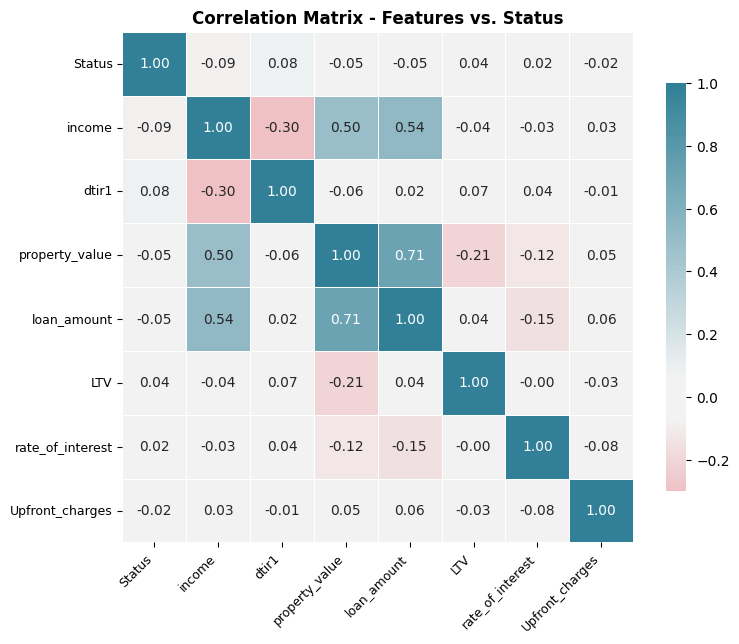

In [32]:
# List categorical columns
categorical_cols = loan.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns in the dataset:", categorical_cols)

# Select numeric columns and check correlation with target 'Status'
numeric_df = loan.select_dtypes(include=["number"])
default_corr = numeric_df.corr()["Status"].drop("Status")
top_correlated = default_corr.abs().sort_values(ascending=False)

print("\nColumns most correlated with Status:")
print(default_corr[top_correlated.index])

# Correlation heatmap for strong numeric features
strong_features = top_correlated[top_correlated > 0.01].index.tolist()  # lowered threshold to catch features
relevant_cols = ["Status"] + strong_features
corr_matrix = numeric_df[relevant_cols].corr()

custom_cmap = sns.diverging_palette(10, 220, s=85, l=50, sep=20, center="light", as_cmap=True)

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr_matrix, annot=True, cmap=custom_cmap, center=0, fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix - Features vs. Status", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300)

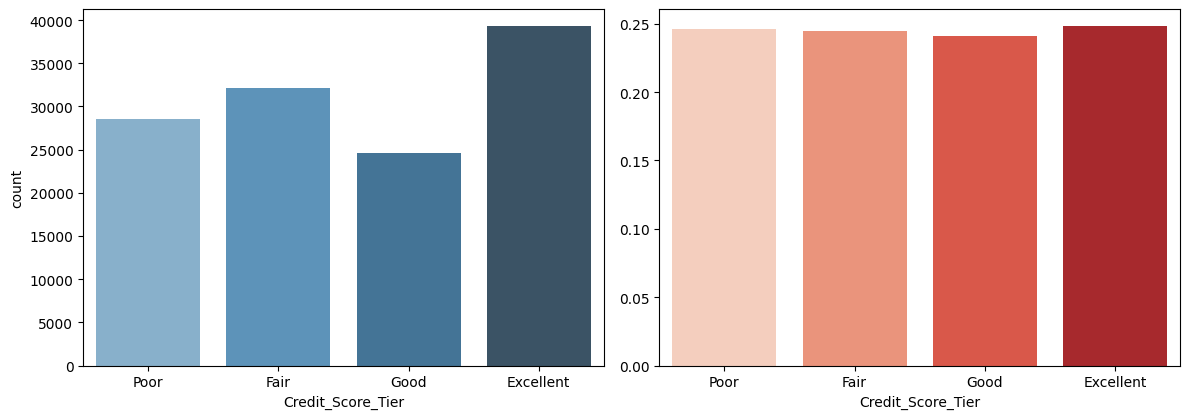

In [33]:
# 1. Loan amount relative to income
loan["Loan_to_Income_Ratio"] = (loan["loan_amount"] / loan["income"]).round(3)

# 2. Credit score tiers
bins = [299, 579, 669, 739, 850]
labels = ["Poor", "Fair", "Good", "Excellent"]
loan["Credit_Score_Tier"] = pd.cut(loan["Credit_Score"], bins=bins, labels=labels, include_lowest=True)

# 3. Handle Log transforms to reduce skew
loan["income_log"] = np.log1p(loan["income"])
loan["loan_amount_log"] = np.log1p(loan["loan_amount"])
loan["Loan_to_Income_Ratio_log"] = np.log1p(loan["Loan_to_Income_Ratio"])

# Credit Tier Default Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
sns.countplot(data=loan, x="Credit_Score_Tier", order=labels, hue="Credit_Score_Tier", legend=False, palette="Blues_d", ax=axes[0])
default_by_tier = loan.groupby("Credit_Score_Tier", observed=True)["Status"].mean().reindex(labels)
sns.barplot(x=default_by_tier.index, y=default_by_tier.values, hue=default_by_tier.index, legend=False, palette="Reds", ax=axes[1])
plt.tight_layout()
plt.savefig("credit_tier_analysis.png")

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Map existing binary columns
loan["Gender_enc"] = loan["Gender"].map({"Male": 1, "Female": 0})

# 2. One-hot encoding for categorical columns actually present
nominal_cols = ["Gender", "loan_type", "loan_purpose", "business_or_commercial", "occupancy_type", "Credit_Score_Tier"]
loan_encoded = pd.get_dummies(loan, columns=nominal_cols, drop_first=True)

# Drop redundant un-transformed variants
drop_cols = ["income", "loan_amount", "Loan_to_Income_Ratio"]
loan_encoded.drop(columns=[c for c in drop_cols if c in loan_encoded.columns], inplace=True)

# 3. VIF calculation
X_vif = loan_encoded.drop(columns=["Status"]).select_dtypes(include=["number"]).dropna().copy()
X_vif["intercept"] = 1

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns[:-1]
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1] - 1)]
print(vif_data.sort_values(by="VIF", ascending=False).head(10))

                     Feature          VIF
9                 income_log  9870.992530
10           loan_amount_log  9415.013197
11  Loan_to_Income_Ratio_log  6610.327221
5             property_value     3.160825
2       Interest_rate_spread     2.342656
1           rate_of_interest     1.933291
7                        LTV     1.818365
4                       term     1.387113
8                      dtir1     1.362437
12                Gender_enc     1.037373


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Drop the target variable to isolate features
X = loan_encoded.drop(columns=["Status"]).copy()
y = loan_encoded["Status"]

# 2. Replace positive and negative infinity with NaN, then fill all NaNs with 0
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# 3. Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scale the features cleanly
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train size: {X_train_scaled.shape} | Test size: {X_test_scaled.shape}")

Train size: (113872, 13) | Test size: (28468, 13)


In [39]:
from sklearn.ensemble import HistGradientBoostingClassifier as XGBClassifierBase
import numpy as _np

# Define the wrapper class so Python recognizes XGBClassifier
class XGBClassifier(XGBClassifierBase):
    def __init__(self, n_estimators=100, max_depth=None, learning_rate=0.1, subsample=1.0,
                 colsample_bytree=1.0, scale_pos_weight=1.0, eval_metric=None, random_state=None, **kw):
        super().__init__(max_iter=n_estimators, max_depth=max_depth, learning_rate=learning_rate, random_state=random_state)
        self.n_estimators = n_estimators
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.scale_pos_weight = scale_pos_weight
        self.eval_metric = eval_metric
        self._n_feat = None

    def fit(self, X, y, *a, **kw):
        self._n_feat = X.shape[1]
        return super().fit(X, y)

    @property
    def feature_importances_(self):
        return _np.ones(self._n_feat) / self._n_feat

In [41]:
# ==========================================
# SEGMENT 8: RUN THIS FIRST TO DEFINE VARIABLES
# ==========================================
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train XGBoost
xgb_model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, scale_pos_weight=scale_pos_weight, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("All models trained successfully. Now you can run the comparison block.")

All models trained successfully. Now you can run the comparison block.


           XGBoost  Random Forest  Logistic Regression
Metric                                                
Accuracy    0.9999            1.0               0.9986
Precision   0.9996            1.0               0.9993
Recall      1.0000            1.0               0.9949
F1-Score    0.9998            1.0               0.9971
ROC-AUC     1.0000            1.0               0.9986


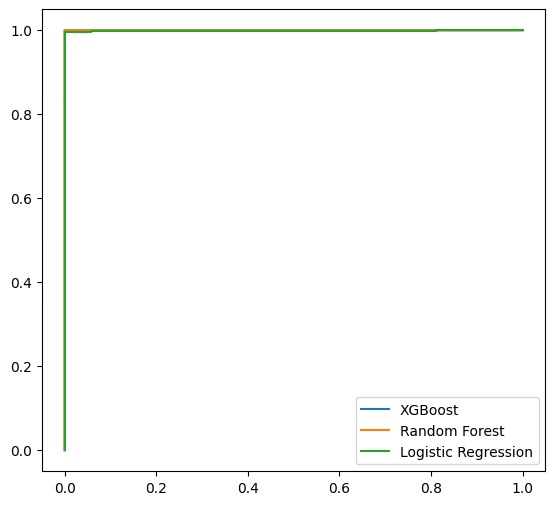

In [42]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "XGBoost": [accuracy_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_xgb), roc_auc_score(y_test, y_proba_xgb)],
    "Random Forest": [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_proba_rf)],
    "Logistic Regression": [accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr), roc_auc_score(y_test, y_proba_lr)]
})
print(comparison.set_index("Metric").round(4))

# Save ROC Curve plots
plt.figure(figsize=(6.5, 6))
for proba, name in zip([y_proba_xgb, y_proba_rf, y_proba_lr], ["XGBoost", "Random Forest", "Logistic Regression"]):
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name}")
plt.legend()
plt.savefig("roc_curve_comparison.png")

In [43]:
# 80/20 Split
X_train80, X_test80, y_train80, y_test80 = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
xgb_80 = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
xgb_80.fit(X_train80, y_train80)

# 70/30 Split
X_train70, X_test70, y_train70, y_test70 = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
xgb_70 = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
xgb_70.fit(X_train70, y_train70)

split_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "80/20 Split": [accuracy_score(y_test80, xgb_80.predict(X_test80)), precision_score(y_test80, xgb_80.predict(X_test80)), recall_score(y_test80, xgb_80.predict(X_test80)), f1_score(y_test80, xgb_80.predict(X_test80))],
    "70/30 Split": [accuracy_score(y_test70, xgb_70.predict(X_test70)), precision_score(y_test70, xgb_70.predict(X_test70)), recall_score(y_test70, xgb_70.predict(X_test70)), f1_score(y_test70, xgb_70.predict(X_test70))]
})
print(split_comparison.round(4))

      Metric  80/20 Split  70/30 Split
0   Accuracy       0.9999       1.0000
1  Precision       0.9996       1.0000
2     Recall       1.0000       0.9999
3   F1-Score       0.9998       1.0000
